In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

nav = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [2]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

c:\Users\91901\AppData\Local\Programs\Python\Python313\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




In [3]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [4]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [5]:
print(aum["year"].unique())

[2022 2023 2024 2025]


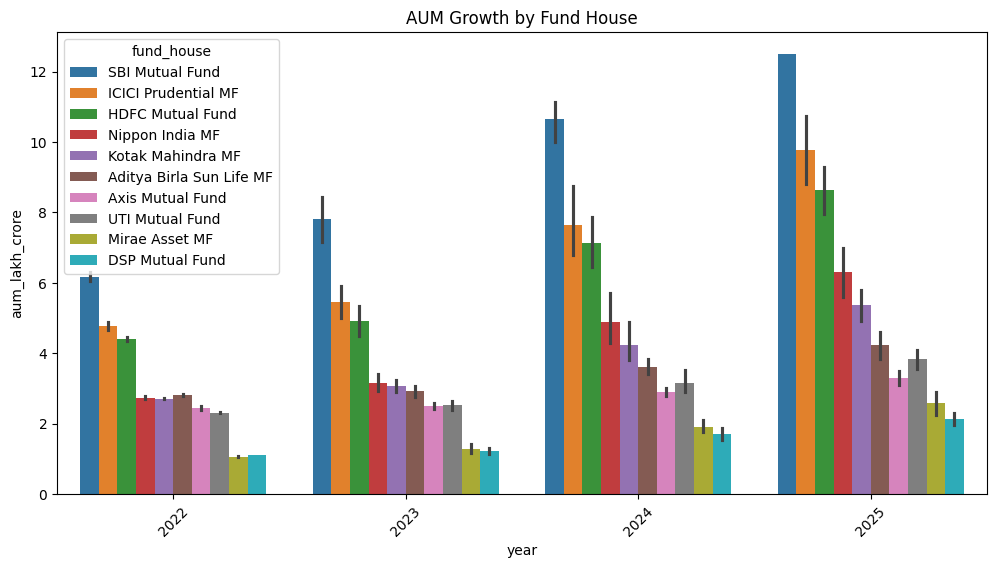

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)
plt.show()

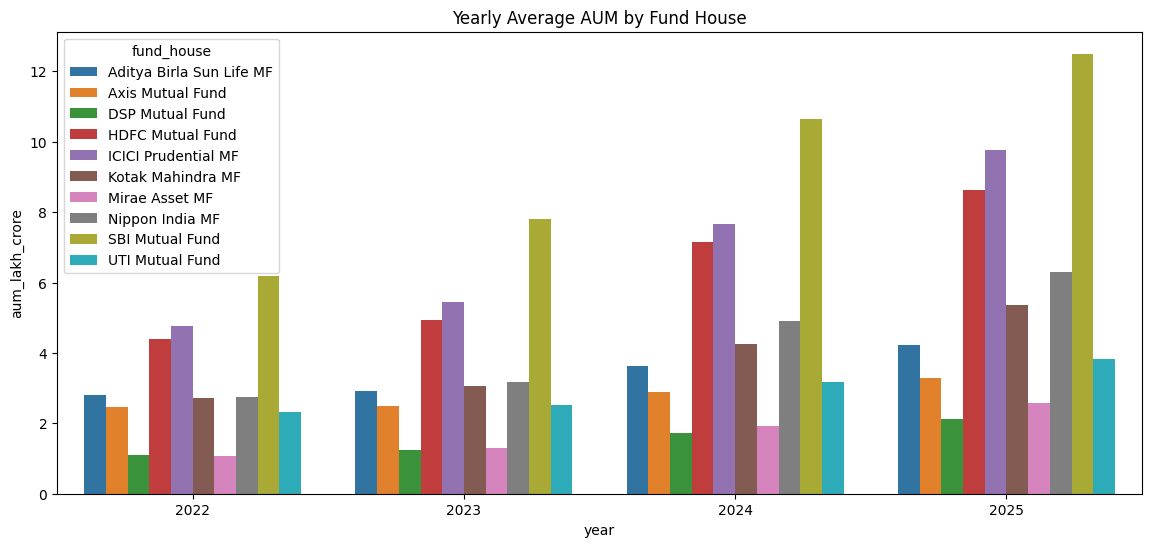

In [7]:
aum_yearly = (
    aum.groupby(["year","fund_house"])["aum_lakh_crore"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Yearly Average AUM by Fund House")
plt.show()

Insight 1

SBI Mutual Fund maintained the highest AUM throughout 2022-2025 and reached approximately ₹12.5 lakh crore in 2025.

Insight 2

ICICI Prudential MF and HDFC Mutual Fund were the second and third largest fund houses by AUM during the period.

Insight 3

All major fund houses showed consistent AUM growth from 2022 to 2025, indicating strong expansion of the mutual fund industry.

In [8]:
plt.savefig("../reports/aum_growth.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [9]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.columns)

sip.head()

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [10]:
import plotly.express as px

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

fig.show()


In [11]:
max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(max_sip)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [12]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

fig.add_scatter(
    x=[max_sip["month"]],
    y=[max_sip["sip_inflow_crore"]],
    mode="markers+text",
    text=["All-Time High ₹31,002 Cr"],
    textposition="top center"
)

fig.show()

In [13]:
pip install kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import kaleido
print("Kaleido installed successfully")


Kaleido installed successfully


In [15]:
pip show kaleido

Name: kaleidoNote: you may need to restart the kernel to use updated packages.

Version: 1.3.0
Summary: Plotly graph export library
Home-page: https://github.com/plotly/kaleido
Author: 
Author-email: Andrew Pikul <ajpikul@gmail.com>, Neyberson Atencio <neyberatencio@gmail.com>
License: The MIT License (MIT)

Copyright (c) Plotly, Inc

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT

In [16]:
import kaleido
print("Kaleido is working")

Kaleido is working


In [17]:
fig.write_image("../reports/sip_inflow_trend.png")

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [18]:
import plotly
print(plotly.__version__)

6.0.0


In [19]:
import kaleido
print(kaleido.__version__)

AttributeError: module 'kaleido' has no attribute '__version__'

In [20]:
plt.savefig("../reports/aum_growth.png")

<Figure size 640x480 with 0 Axes>

In [21]:
fig.show()

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat = pd.read_csv("../data/raw/05_category_inflows.csv")

print(cat.columns)
cat.head()

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


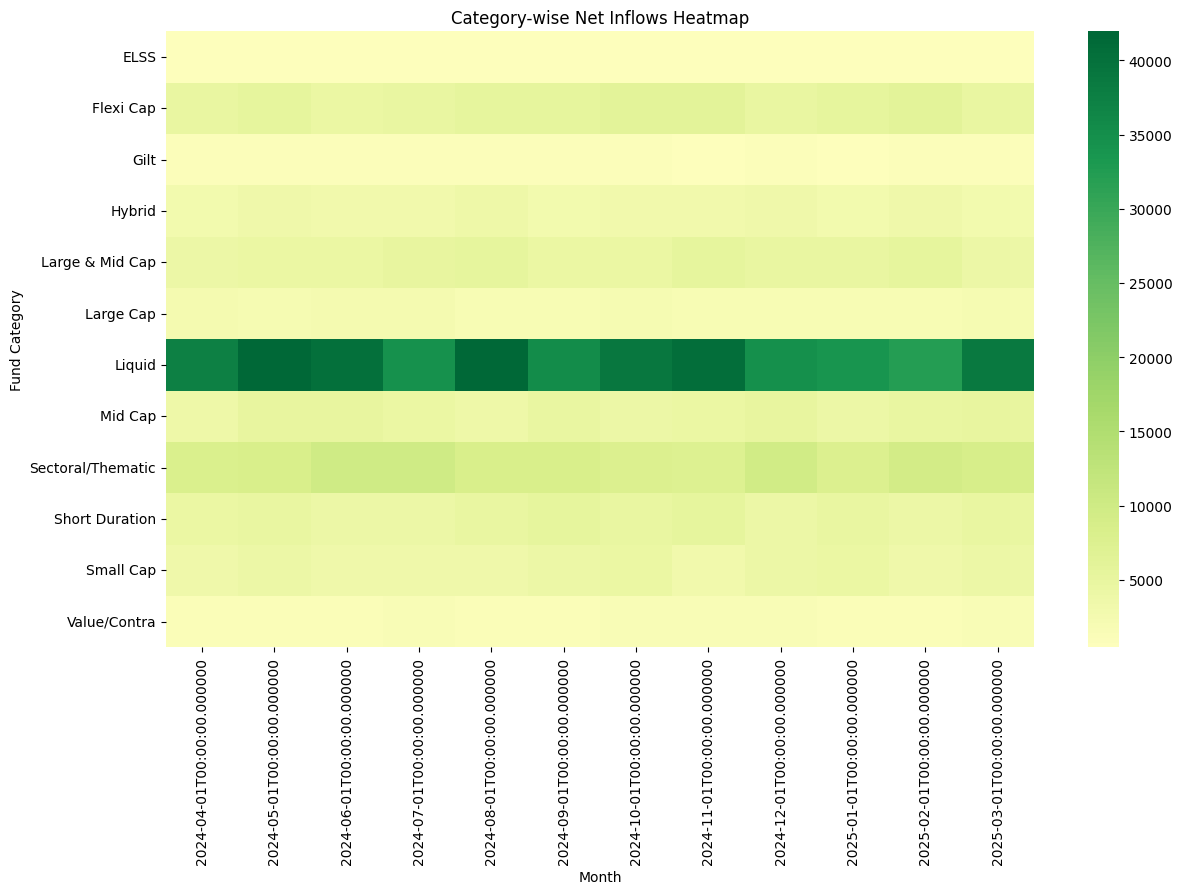

In [23]:
cat["month"] = pd.to_datetime(cat["month"])

heatmap_data = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap="RdYlGn", center=0)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

In [24]:
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(txn.columns)
txn.head()

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


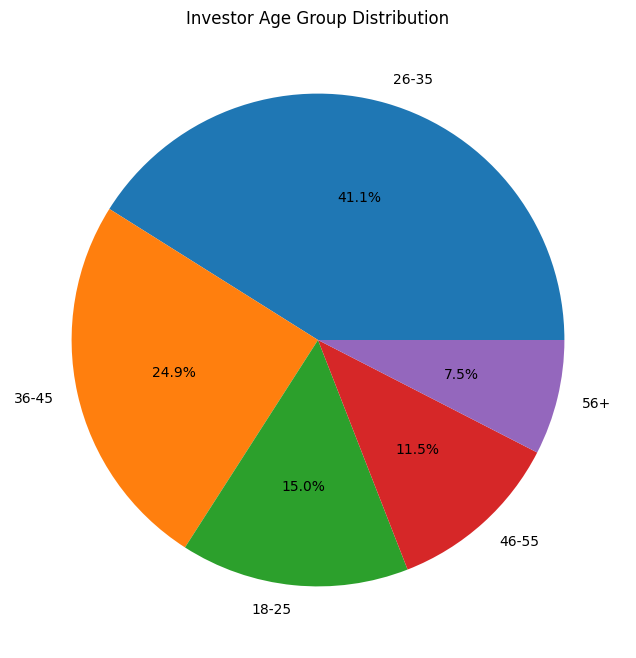

In [25]:
plt.figure(figsize=(8,8))

txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

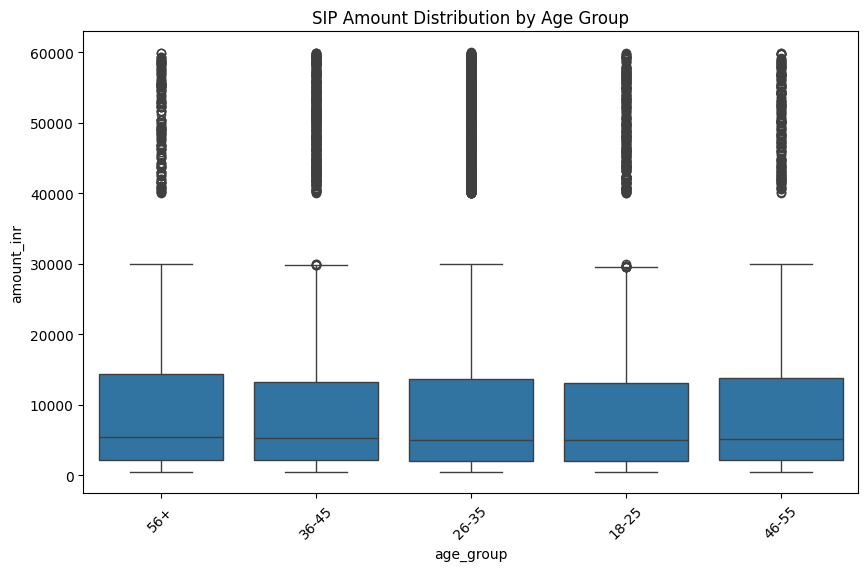

In [26]:
sip_txn = txn[txn["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xticks(rotation=45)
plt.show()

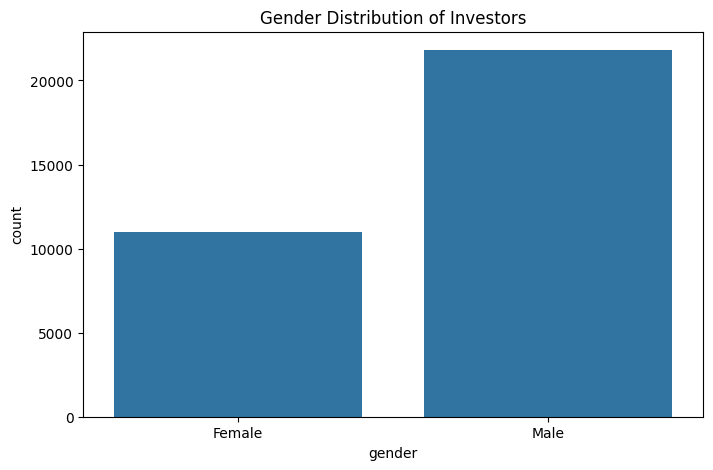

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=txn,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.show()

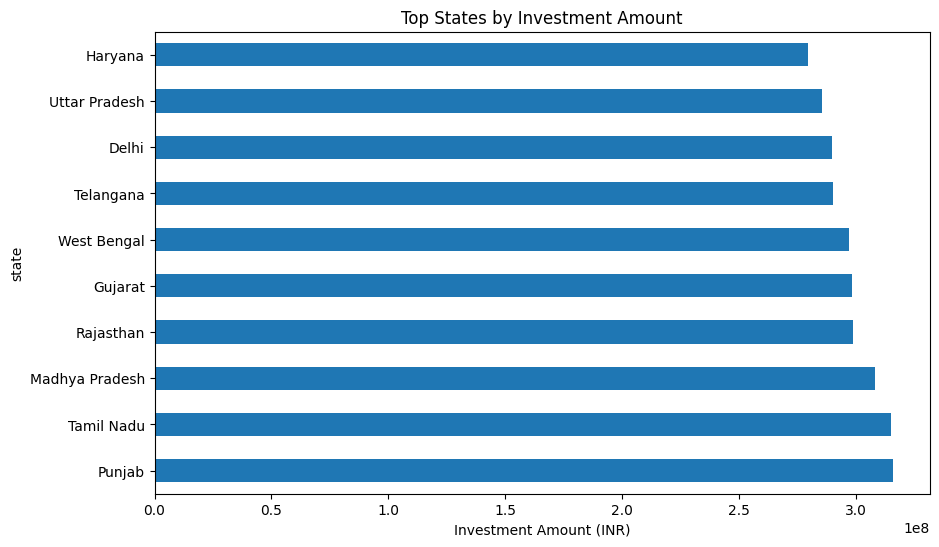

In [28]:
state_data = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

state_data.plot(kind="barh")

plt.title("Top States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.show()

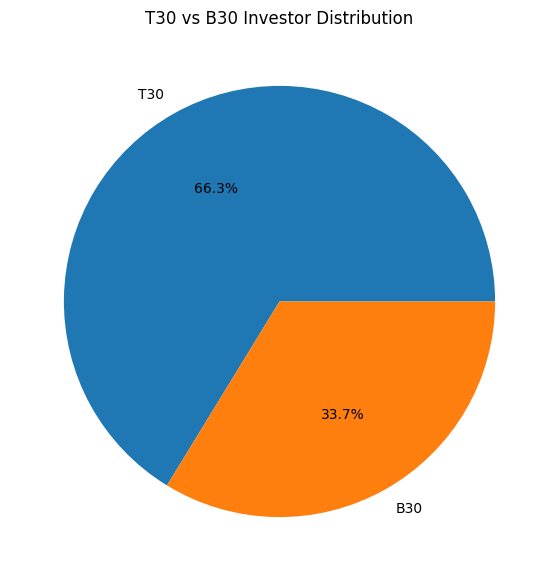

In [29]:
txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")
plt.show()

In [30]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns)
folio.head()

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


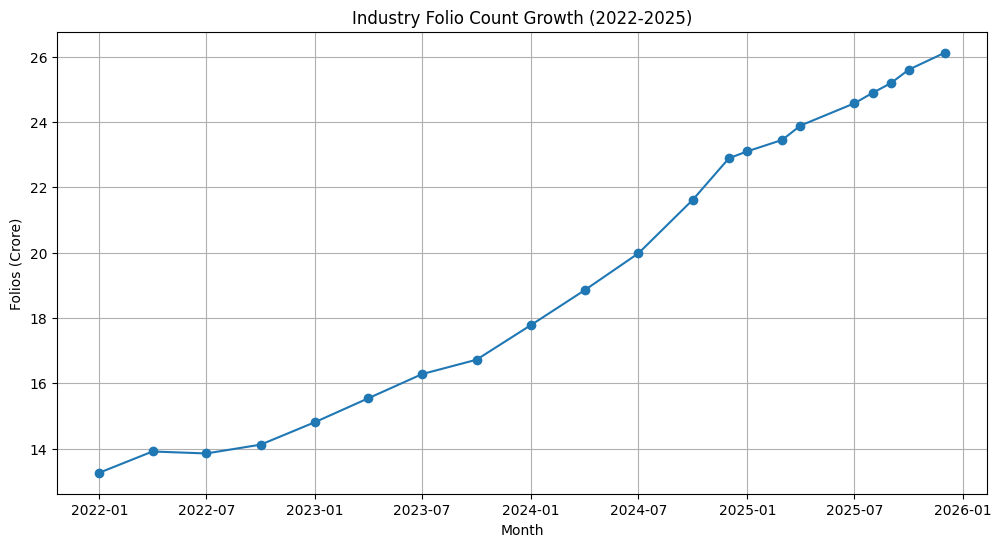

In [31]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)

plt.show()

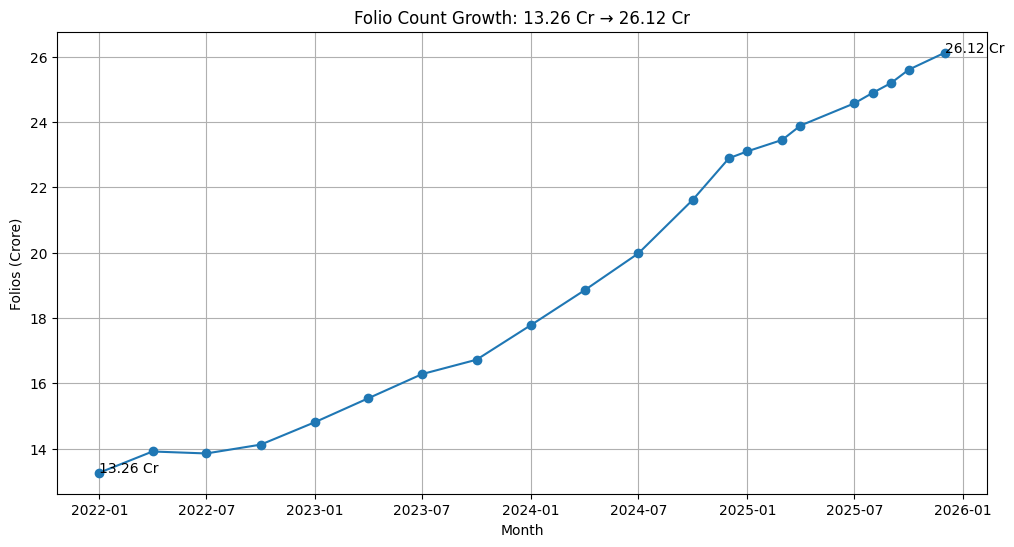

In [32]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    xy=(folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"])
)

plt.title("Folio Count Growth: 13.26 Cr → 26.12 Cr")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)

plt.show()

In [33]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


print(nav["amfi_code"].nunique())
print(nav["amfi_code"].unique()[:10])

In [34]:
nav["date"] = pd.to_datetime(nav["date"])

pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_nav.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [35]:
returns = pivot_nav.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,...,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


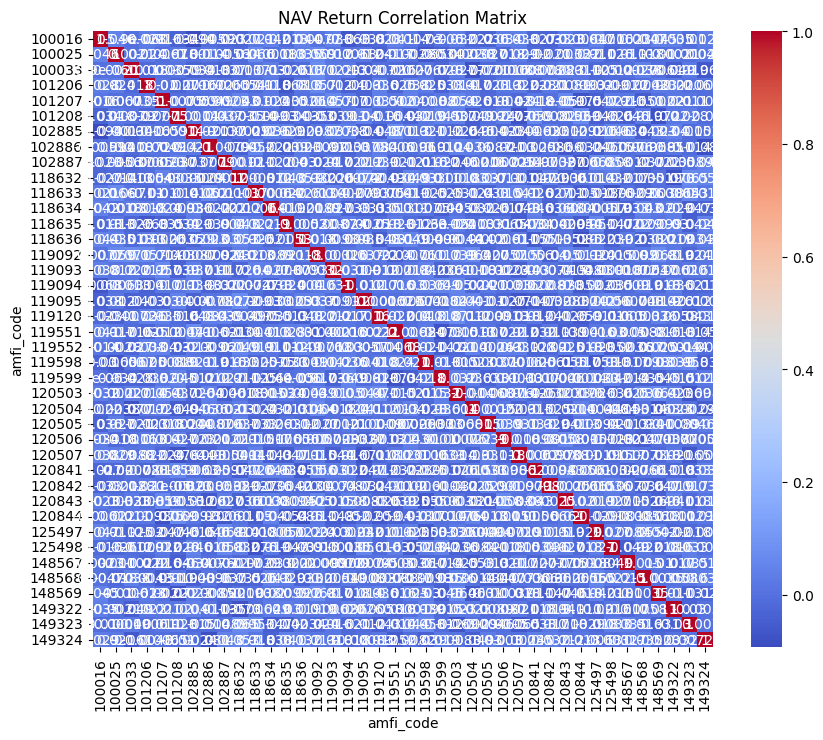

In [36]:
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

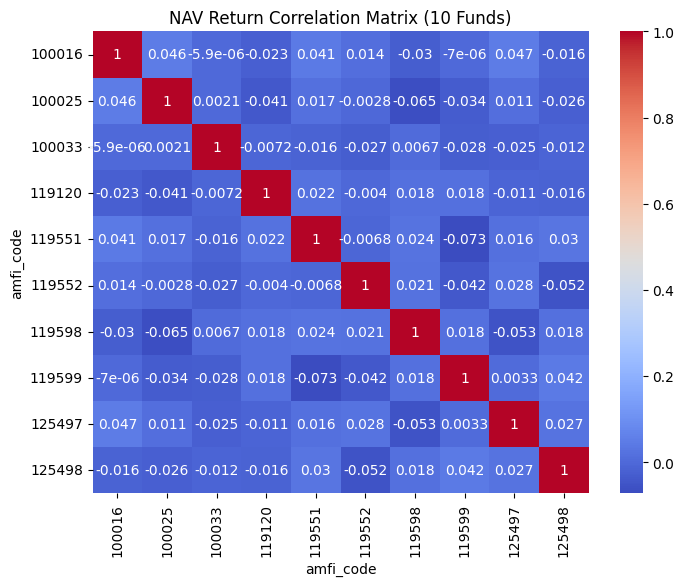

In [37]:
selected_funds = nav["amfi_code"].unique()[:10]

nav_small = nav[nav["amfi_code"].isin(selected_funds)]

pivot_nav = nav_small.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change().dropna()

corr_matrix = returns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix (10 Funds)")
plt.show()

In [38]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.columns)

portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [39]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


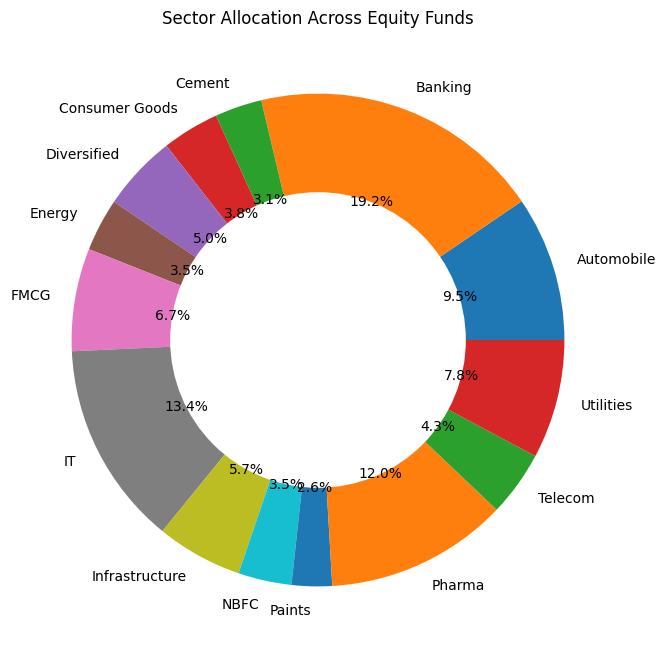

In [40]:
sector_weights = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

# Key EDA Findings

1. SBI Mutual Fund maintained the highest AUM across all years, reaching approximately ₹12.5 lakh crore in 2025.

2. Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, nearly doubling investor participation.

3. Monthly SIP inflows reached an all-time high of ₹31,002 crore in December 2025.

4. Equity folios contributed the majority share of total folios throughout the period.

5. Investors aged 26-35 formed the largest investor segment, contributing over 40% of total investors.

6. Male investors represented a significantly larger share compared to female investors.

7. T30 cities contributed nearly two-thirds of total investment activity.

8. Banking, Utilities, Pharma, and Diversified sectors occupied a major share of portfolio allocations.

9. Most mutual funds showed weak-to-moderate correlation in daily returns, indicating diversification opportunities.

10. Category inflows remained strongest in equity-oriented categories during the observed period.